# Global Wheat Head: New Data Domain Inspection

This notebook inspects newly generated augmentation data for Global Wheat Head and answers:

1. How many augmented images were added for each domain?
2. What is AP for each domain (baseline vs augmented conditions)?
3. What is the AP difference vs baseline for each domain?

It is designed for the experiment output in `results/13_multiseed_score_vs_noscore_copy_paste_exp_global_wheat_head`.

In [1]:
from __future__ import annotations

import json
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

try:
    from ultralytics import YOLO
except ImportError as exc:
    raise ImportError(
        "ultralytics is required for per-domain AP evaluation. Install with: pip install ultralytics"
    ) from exc

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

PROJECT_ROOT = Path('/home/khanh/Projects/DifficultyAgri')
RESULTS_ROOT = PROJECT_ROOT / 'results' / '13_multiseed_score_vs_noscore_copy_paste_exp_global_wheat_head'
SUMMARY_PATH = RESULTS_ROOT / 'summary_score_vs_without_score_3seeds.json'
RAW_ROOT = PROJECT_ROOT / 'datasets' / 'global_wheat_head' / 'raw'
TEST_IMAGES_DIR = PROJECT_ROOT / 'datasets' / 'global_wheat_head' / 'yolo_format' / 'global_wheat_head_yolo' / 'test' / 'images'
CACHE_ROOT = PROJECT_ROOT / '.cache_result' / 'no_trad_aug' / 'gwhd'

IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}
DEFAULT_SEED = 123
RUN_DOMAIN_AP = True
CONF_THRES = 0.001
IOU_THRES = 0.6

assert RESULTS_ROOT.exists(), f'Missing results root: {RESULTS_ROOT}'
assert SUMMARY_PATH.exists(), f'Missing summary: {SUMMARY_PATH}'
assert RAW_ROOT.exists(), f'Missing raw dataset root: {RAW_ROOT}'
assert TEST_IMAGES_DIR.exists(), f'Missing test images dir: {TEST_IMAGES_DIR}'

print('RESULTS_ROOT:', RESULTS_ROOT)
print('SUMMARY_PATH:', SUMMARY_PATH)
print('RAW_ROOT:', RAW_ROOT)
print('TEST_IMAGES_DIR:', TEST_IMAGES_DIR)
print('DEFAULT_SEED:', DEFAULT_SEED)
print('RUN_DOMAIN_AP:', RUN_DOMAIN_AP)

RESULTS_ROOT: /home/khanh/Projects/DifficultyAgri/results/13_multiseed_score_vs_noscore_copy_paste_exp_global_wheat_head
SUMMARY_PATH: /home/khanh/Projects/DifficultyAgri/results/13_multiseed_score_vs_noscore_copy_paste_exp_global_wheat_head/summary_score_vs_without_score_3seeds.json
RAW_ROOT: /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/raw
TEST_IMAGES_DIR: /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format/global_wheat_head_yolo/test/images
DEFAULT_SEED: 123
RUN_DOMAIN_AP: True


In [2]:
def load_json(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

def build_domain_map_from_raw_json(raw_root: Path) -> dict[str, str]:
    domain_map: dict[str, str] = {}
    for domain_json in sorted(raw_root.glob('*.json')):
        domain_name = domain_json.stem
        payload = load_json(domain_json)
        for image_info in payload.get('images', []):
            file_name = image_info.get('file_name', '')
            image_path = image_info.get('path', '')
            stem = Path(file_name).stem if file_name else Path(image_path).stem
            if stem:
                domain_map[stem] = domain_name
    return domain_map

def collect_added_images_by_domain(experiment_root: Path, conditions: list[str], seeds: list[int], domain_map: dict[str, str]) -> pd.DataFrame:
    rows: list[dict] = []
    for condition in conditions:
        for seed in seeds:
            metadata_dir = (
                experiment_root
                / f'seed_{seed}'
                / 'Step_4_Copy_Paste_Augmentation'
                / condition
                / 'augmented_dataset'
                / 'train'
                / 'metadata'
            )
            if not metadata_dir.exists():
                continue

            for meta_path in sorted(metadata_dir.glob('aug_*.json')):
                payload = load_json(meta_path)
                background_name = payload.get('background_image_name', '')
                bg_stem = Path(background_name).stem if background_name else ''
                rows.append({
                    'seed': int(seed),
                    'condition': condition,
                    'augmented_image': meta_path.stem,
                    'background_image_name': background_name,
                    'background_stem': bg_stem,
                    'background_domain': domain_map.get(bg_stem, 'unknown'),
                    'pasted_object_count': int(payload.get('pasted_object_count', 0)),
                    'selected_object_count': int(payload.get('selected_object_count', 0)),
                })

    return pd.DataFrame(rows)

def summarize_added_images(added_df: pd.DataFrame) -> pd.DataFrame:
    if added_df.empty:
        return pd.DataFrame()

    out = (
        added_df.groupby(['seed', 'condition', 'background_domain'], as_index=False)
        .agg(
            augmented_images_added=('augmented_image', 'nunique'),
            unique_background_images_used=('background_stem', 'nunique'),
            total_pasted_objects=('pasted_object_count', 'sum'),
            avg_pasted_objects_per_augmented_image=('pasted_object_count', 'mean'),
        )
        .sort_values(['condition', 'seed', 'augmented_images_added'], ascending=[True, True, False])
        .reset_index(drop=True)
    )
    return out

def build_test_paths_by_domain(test_images_dir: Path, domain_map: dict[str, str]) -> dict[str, list[str]]:
    paths_by_domain: dict[str, list[str]] = {}
    for image_path in sorted(test_images_dir.glob('*')):
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        domain = domain_map.get(image_path.stem, 'unknown')
        paths_by_domain.setdefault(domain, []).append(str(image_path.resolve()))

    for domain in list(paths_by_domain):
        paths_by_domain[domain] = sorted(paths_by_domain[domain])

    return dict(sorted(paths_by_domain.items(), key=lambda kv: kv[0]))

def write_domain_subset_data_yaml(base_data_yaml: Path, domain: str, test_image_paths: list[str], out_dir: Path) -> Path:
    cfg = load_yaml(base_data_yaml)
    out_dir.mkdir(parents=True, exist_ok=True)

    test_list_path = out_dir / f'test_{domain}.txt'
    with test_list_path.open('w', encoding='utf-8') as f:
        for p in test_image_paths:
            f.write(f'{p}\n')

    subset_cfg = {
        'path': cfg.get('path', ''),
        'train': cfg.get('train', ''),
        'val': cfg.get('val', ''),
        'test': str(test_list_path),
        'nc': cfg.get('nc', 1),
        'names': cfg.get('names', {0: 'wheat_head'}),
    }

    out_yaml = out_dir / f'data_{domain}.yaml'
    with out_yaml.open('w', encoding='utf-8') as f:
        yaml.safe_dump(subset_cfg, f, sort_keys=False)

    return out_yaml

def load_yaml(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as f:
        return yaml.safe_load(f)

def eval_domain_ap(model_path: Path, data_yaml: Path, conf: float = 0.001, iou: float = 0.6, imgsz: int = 640, device: str = 'cpu') -> dict:
    model = YOLO(str(model_path))
    metrics = model.val(data=str(data_yaml), split='test', imgsz=imgsz, conf=conf, iou=iou, device=device, verbose=False)

    ap = float(getattr(metrics.box, 'map', np.nan))
    ap50 = float(getattr(metrics.box, 'map50', np.nan))
    ap75 = float(getattr(metrics.box, 'map75', np.nan))
    aps = getattr(metrics.box, 'maps', [])
    ap_class0 = float(aps[0]) if aps is not None and len(aps) > 0 else ap

    return {
        'COCO_AP': ap,
        'COCO_AP50': ap50,
        'COCO_AP75': ap75,
        'AP_class0': ap_class0,
    }

In [3]:
summary = load_json(SUMMARY_PATH)
domain_map = build_domain_map_from_raw_json(RAW_ROOT)
seeds = [int(s) for s in summary.get('seeds', [DEFAULT_SEED])]
conditions = list(summary.get('conditions', {}).keys())

added_raw_df = collect_added_images_by_domain(RESULTS_ROOT, conditions, seeds, domain_map)
added_summary_df = summarize_added_images(added_raw_df)

print(f'Domain map entries: {len(domain_map):,}')
print(f'Seeds: {seeds}')
print(f'Conditions: {conditions}')
print(f'Augmented metadata rows: {len(added_raw_df):,}')
display(added_summary_df.head(30))

Domain map entries: 3,422
Seeds: [123, 456, 789]
Conditions: ['with_score', 'without_score']
Augmented metadata rows: 8,100


,seed,condition,background_domain,augmented_images_added,unique_background_images_used,total_pasted_objects,avg_pasted_objects_per_augmented_image
0,123,with_score,arvalis_1,582,582,2916,5.010309
1,123,with_score,arvalis_3,252,252,1136,4.507937
2,123,with_score,ethz_1,158,158,788,4.987342
3,123,with_score,arvalis_2,151,151,754,4.993377
4,123,with_score,usask_1,99,99,458,4.626263
5,123,with_score,rres_1,57,57,288,5.052632
6,123,with_score,inrae_1,51,51,234,4.588235
7,456,with_score,arvalis_1,595,595,2888,4.853782
8,456,with_score,arvalis_3,260,260,1266,4.869231
9,456,with_score,arvalis_2,157,157,781,4.974522


,seed,condition,background_domain,augmented_images_added,unique_background_images_used,total_pasted_objects,avg_pasted_objects_per_augmented_image
0,123,with_score,arvalis_1,582,582,2916,5.010309
1,123,with_score,arvalis_3,252,252,1136,4.507937
2,123,with_score,ethz_1,158,158,788,4.987342
3,123,with_score,arvalis_2,151,151,754,4.993377
4,123,with_score,usask_1,99,99,458,4.626263
5,123,with_score,rres_1,57,57,288,5.052632
6,123,with_score,inrae_1,51,51,234,4.588235
21,123,without_score,arvalis_1,428,428,2056,4.803738
22,123,without_score,ethz_1,297,297,1504,5.063973
23,123,without_score,arvalis_3,220,220,1026,4.663636


condition,with_score,without_score
background_domain,,
arvalis_1,582,428
arvalis_2,151,71
arvalis_3,252,220
ethz_1,158,297
inrae_1,51,57
rres_1,57,193
usask_1,99,84


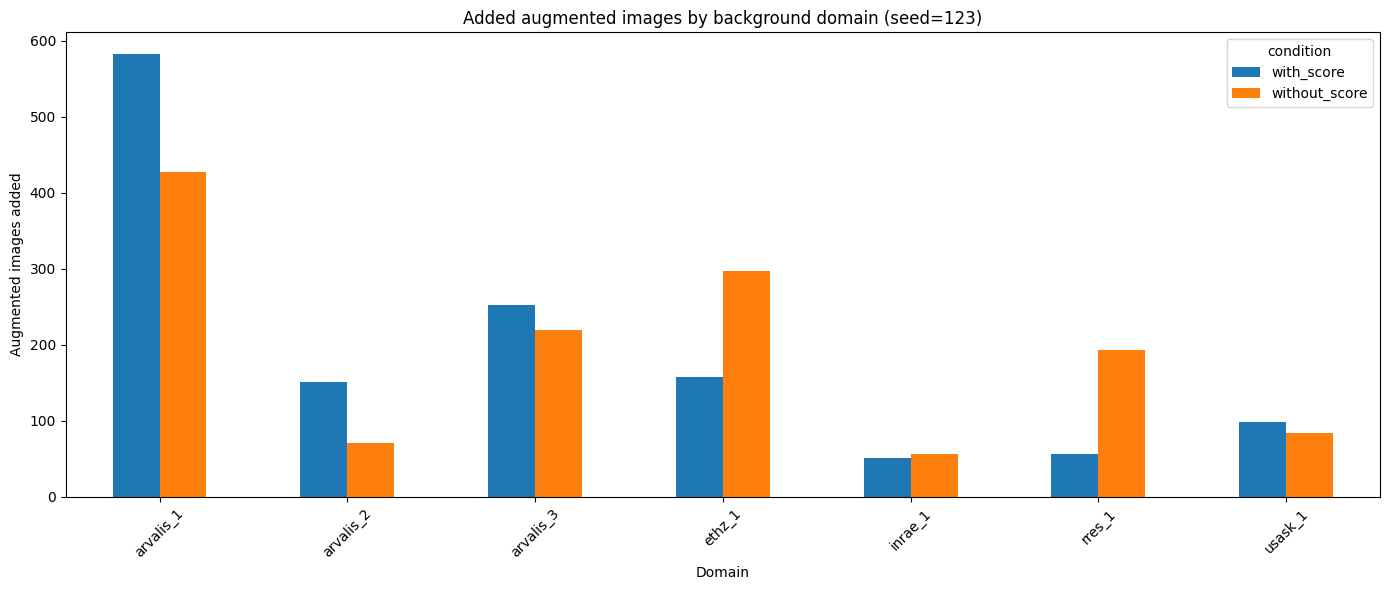

In [4]:
if added_summary_df.empty:
    raise RuntimeError('No augmented metadata found to analyze image additions by domain.')

seed_for_display = DEFAULT_SEED
seed_view_df = added_summary_df[added_summary_df['seed'] == seed_for_display].copy()
display(seed_view_df.sort_values(['condition', 'augmented_images_added'], ascending=[True, False]))

pivot_added = seed_view_df.pivot(index='background_domain', columns='condition', values='augmented_images_added').fillna(0).astype(int)
pivot_added = pivot_added.sort_index()
display(pivot_added)

fig, ax = plt.subplots(figsize=(14, 6))
pivot_added.plot(kind='bar', ax=ax)
ax.set_title(f'Added augmented images by background domain (seed={seed_for_display})')
ax.set_ylabel('Augmented images added')
ax.set_xlabel('Domain')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Per-domain AP (baseline vs augmented)

This section evaluates AP on each test domain for one seed.

- baseline checkpoint: `.cache_result/no_trad_aug/gwhd/baseline/seed_{seed}/best.pt`
- with_score checkpoint: Step 5 `with_score/train_results/best.pt`
- without_score checkpoint: Step 5 `without_score/train_results/best.pt`

Set `RUN_DOMAIN_AP = False` in Cell 2 to skip heavy evaluation.

In [5]:
seed = DEFAULT_SEED
base_data_yaml = (
    RESULTS_ROOT
    / f'seed_{seed}'
    / 'Step_5_Train_and_Evaluate_Model_on_Augmented_Dataset'
    / 'with_score'
    / 'train_results'
    / 'data.yaml'
)

model_paths = {
    'baseline': CACHE_ROOT / 'baseline' / f'seed_{seed}' / 'best.pt',
    'with_score': RESULTS_ROOT / f'seed_{seed}' / 'Step_5_Train_and_Evaluate_Model_on_Augmented_Dataset' / 'with_score' / 'train_results' / 'best.pt',
    'without_score': RESULTS_ROOT / f'seed_{seed}' / 'Step_5_Train_and_Evaluate_Model_on_Augmented_Dataset' / 'without_score' / 'train_results' / 'best.pt',
}

for name, p in model_paths.items():
    if not p.exists():
        raise FileNotFoundError(f'Missing model for {name}: {p}')
if not base_data_yaml.exists():
    raise FileNotFoundError(f'Missing base data yaml: {base_data_yaml}')

test_paths_by_domain = build_test_paths_by_domain(TEST_IMAGES_DIR, domain_map)
print(f'Domains in test split: {len(test_paths_by_domain)}')
for d, paths in test_paths_by_domain.items():
    print(f'  {d}: {len(paths)} images')

domain_ap_rows = []
if RUN_DOMAIN_AP:
    with tempfile.TemporaryDirectory(prefix='gwhd_domain_ap_') as tmp_dir:
        tmp_root = Path(tmp_dir)
        for domain, image_paths in test_paths_by_domain.items():
            if domain == 'unknown' or len(image_paths) == 0:
                continue

            domain_yaml = write_domain_subset_data_yaml(base_data_yaml, domain, image_paths, tmp_root)
            for condition, model_path in model_paths.items():
                ap_metrics = eval_domain_ap(
                    model_path=model_path,
                    data_yaml=domain_yaml,
                    conf=CONF_THRES,
                    iou=IOU_THRES,
                    device='cpu',
                )
                domain_ap_rows.append({
                    'seed': int(seed),
                    'condition': condition,
                    'domain': domain,
                    'test_images': len(image_paths),
                    **ap_metrics,
                })

domain_ap_df = pd.DataFrame(domain_ap_rows)
display(domain_ap_df.head(20))
print('Rows in domain_ap_df:', len(domain_ap_df))

if not RUN_DOMAIN_AP:
    print('RUN_DOMAIN_AP is False. Set RUN_DOMAIN_AP=True in Cell 2 to run per-domain AP evaluation.')

Domains in test split: 7
  arvalis_1: 113 images
  arvalis_2: 24 images
  arvalis_3: 46 images
  ethz_1: 74 images
  inrae_1: 17 images
  rres_1: 41 images
  usask_1: 24 images
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0+cu128 CPU (Intel Core Ultra 9 285K)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6699.4±5616.9 MB/s, size: 2273.1 KB)
val: Scanning /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format/global_wheat_head_yolo/test/labels... 113 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 113/113 317.6it/s 0.4s1s
val: New cache created: /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format/global_wheat_head_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.2s/it 9.9s1.4ss
                   all        113       5053      0.744      0.684       0.73      0.293
Spe

,seed,condition,domain,test_images,COCO_AP,COCO_AP50,COCO_AP75,AP_class0
0,123,baseline,arvalis_1,113,0.292507,0.729858,0.152555,0.292507
1,123,with_score,arvalis_1,113,0.248352,0.646503,0.123068,0.248352
2,123,without_score,arvalis_1,113,0.257960,0.657207,0.138178,0.257960
3,123,baseline,arvalis_2,24,0.192443,0.550355,0.078770,0.192443
4,123,with_score,arvalis_2,24,0.151180,0.443030,0.048908,0.151180
5,123,without_score,arvalis_2,24,0.143152,0.443381,0.047491,0.143152
6,123,baseline,arvalis_3,46,0.418703,0.845027,0.356589,0.418703
7,123,with_score,arvalis_3,46,0.370450,0.790228,0.263724,0.370450
8,123,without_score,arvalis_3,46,0.373262,0.805310,0.273029,0.373262
9,123,baseline,ethz_1,74,0.394281,0.851784,0.287695,0.394281


Rows in domain_ap_df: 21


,seed,condition,domain,test_images,COCO_AP,COCO_AP50,COCO_AP75,AP_class0,baseline_COCO_AP,baseline_COCO_AP50,baseline_COCO_AP75,delta_vs_baseline_COCO_AP,delta_vs_baseline_COCO_AP50,delta_vs_baseline_COCO_AP75,augmented_images_added
0,123,baseline,arvalis_1,113,0.292507,0.729858,0.152555,0.292507,0.292507,0.729858,0.152555,0.000000,0.000000,0.000000,NaN
1,123,baseline,arvalis_2,24,0.192443,0.550355,0.078770,0.192443,0.192443,0.550355,0.078770,0.000000,0.000000,0.000000,NaN
2,123,baseline,arvalis_3,46,0.418703,0.845027,0.356589,0.418703,0.418703,0.845027,0.356589,0.000000,0.000000,0.000000,NaN
3,123,baseline,ethz_1,74,0.394281,0.851784,0.287695,0.394281,0.394281,0.851784,0.287695,0.000000,0.000000,0.000000,NaN
4,123,baseline,inrae_1,17,0.540552,0.951247,0.555454,0.540552,0.540552,0.951247,0.555454,0.000000,0.000000,0.000000,NaN
5,123,baseline,rres_1,41,0.473486,0.855893,0.480296,0.473486,0.473486,0.855893,0.480296,0.000000,0.000000,0.000000,NaN
6,123,baseline,usask_1,24,0.359067,0.797427,0.253944,0.359067,0.359067,0.797427,0.253944,0.000000,0.000000,0.000000,NaN
7,123,with_score,arvalis_1,113,0.248352,0.646503,0.123068,0.248352,0.292507,0.729858,0.152555,-0.044155,-0.083356,-0.029488,582.0
8,123,with_score,arvalis_2,24,0.151180,0.443030,0.048908,0.151180,0.192443,0.550355,0.078770,-0.041263,-0.107325,-0.029862,151.0
9,123,with_score,arvalis_3,46,0.370450,0.790228,0.263724,0.370450,0.418703,0.845027,0.356589,-0.048252,-0.054799,-0.092864,252.0


condition,baseline,with_score,without_score
domain,,,
arvalis_1,0.292507,0.248352,0.257960
arvalis_2,0.192443,0.151180,0.143152
arvalis_3,0.418703,0.370450,0.373262
ethz_1,0.394281,0.391052,0.368101
inrae_1,0.540552,0.457582,0.476874
rres_1,0.473486,0.472718,0.498104
usask_1,0.359067,0.355739,0.371670


condition,with_score,without_score
domain,,
arvalis_1,-0.044155,-0.034547
arvalis_2,-0.041263,-0.049291
arvalis_3,-0.048252,-0.045440
ethz_1,-0.003229,-0.026180
inrae_1,-0.082970,-0.063679
rres_1,-0.000768,0.024618
usask_1,-0.003329,0.012602


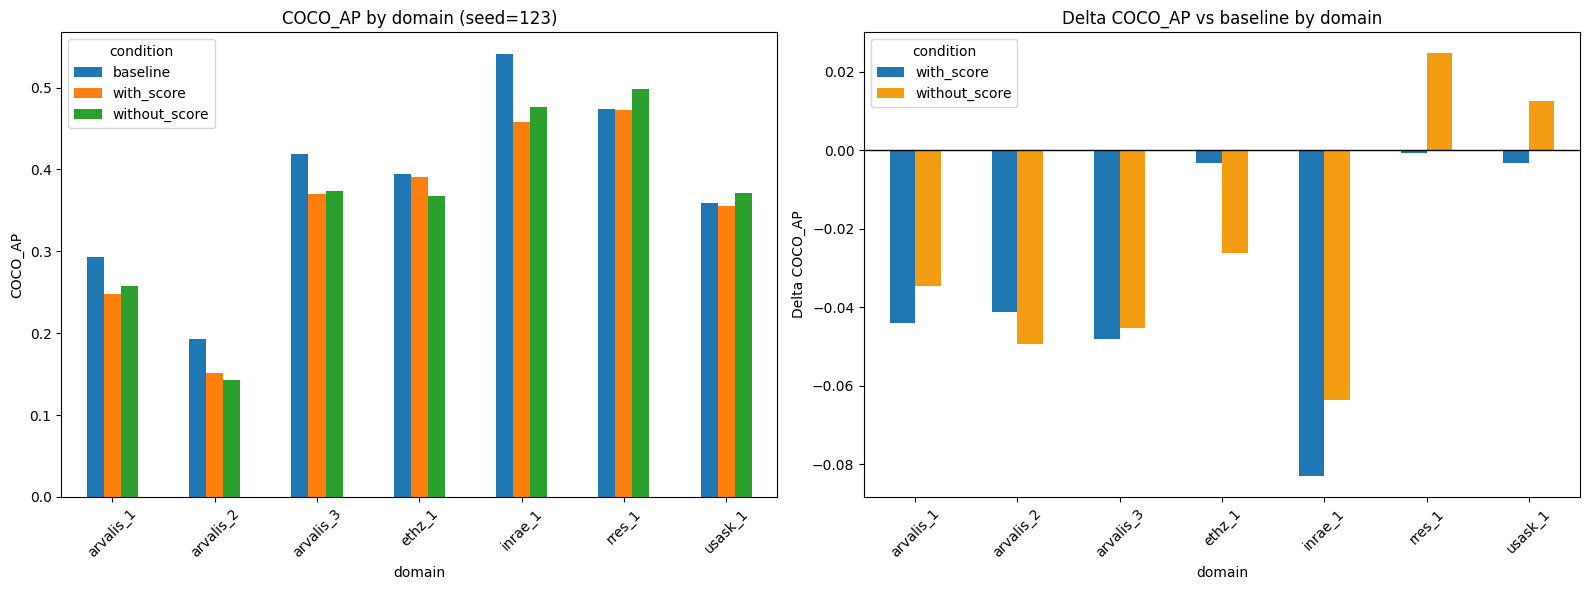

,condition,domain,test_images,augmented_images_added,COCO_AP,baseline_COCO_AP,delta_vs_baseline_COCO_AP
16,with_score,rres_1,41,57.0,0.472718,0.473486,-0.000768
10,with_score,ethz_1,74,158.0,0.391052,0.394281,-0.003229
19,with_score,usask_1,24,99.0,0.355739,0.359067,-0.003329
4,with_score,arvalis_2,24,151.0,0.151180,0.192443,-0.041263
1,with_score,arvalis_1,113,582.0,0.248352,0.292507,-0.044155
7,with_score,arvalis_3,46,252.0,0.370450,0.418703,-0.048252
13,with_score,inrae_1,17,51.0,0.457582,0.540552,-0.082970
17,without_score,rres_1,41,193.0,0.498104,0.473486,0.024618
20,without_score,usask_1,24,84.0,0.371670,0.359067,0.012602
11,without_score,ethz_1,74,297.0,0.368101,0.394281,-0.026180


In [6]:
if RUN_DOMAIN_AP and not domain_ap_df.empty:
    baseline_df = domain_ap_df[domain_ap_df['condition'] == 'baseline'][['domain', 'COCO_AP', 'COCO_AP50', 'COCO_AP75']].rename(
        columns={
            'COCO_AP': 'baseline_COCO_AP',
            'COCO_AP50': 'baseline_COCO_AP50',
            'COCO_AP75': 'baseline_COCO_AP75',
        }
    )

    compare_df = domain_ap_df.merge(baseline_df, on='domain', how='left')
    compare_df['delta_vs_baseline_COCO_AP'] = compare_df['COCO_AP'] - compare_df['baseline_COCO_AP']
    compare_df['delta_vs_baseline_COCO_AP50'] = compare_df['COCO_AP50'] - compare_df['baseline_COCO_AP50']
    compare_df['delta_vs_baseline_COCO_AP75'] = compare_df['COCO_AP75'] - compare_df['baseline_COCO_AP75']

    added_seed_df = added_summary_df[
        (added_summary_df['seed'] == seed)
        & (added_summary_df['condition'].isin(['with_score', 'without_score']))
    ][['condition', 'background_domain', 'augmented_images_added']]

    compare_df = compare_df.merge(
        added_seed_df,
        left_on=['condition', 'domain'],
        right_on=['condition', 'background_domain'],
        how='left',
    ).drop(columns=['background_domain'])

    display(compare_df.sort_values(['condition', 'domain']).reset_index(drop=True))

    ap_pivot = compare_df.pivot(index='domain', columns='condition', values='COCO_AP')
    display(ap_pivot.sort_index())

    delta_pivot = compare_df[compare_df['condition'].isin(['with_score', 'without_score'])].pivot(
        index='domain', columns='condition', values='delta_vs_baseline_COCO_AP'
    )
    display(delta_pivot.sort_index())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ap_pivot.sort_index().plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'COCO_AP by domain (seed={seed})')
    axes[0].set_ylabel('COCO_AP')
    axes[0].tick_params(axis='x', rotation=45)

    delta_pivot.sort_index().plot(kind='bar', ax=axes[1], color=['#1f77b4', '#f39c12'])
    axes[1].axhline(0.0, color='black', linewidth=1)
    axes[1].set_title('Delta COCO_AP vs baseline by domain')
    axes[1].set_ylabel('Delta COCO_AP')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    summary_table = compare_df[compare_df['condition'].isin(['with_score', 'without_score'])][
        ['condition', 'domain', 'test_images', 'augmented_images_added', 'COCO_AP', 'baseline_COCO_AP', 'delta_vs_baseline_COCO_AP']
    ].sort_values(['condition', 'delta_vs_baseline_COCO_AP'], ascending=[True, False])
    display(summary_table)
else:
    print('No per-domain AP comparison available yet. Run Cell 7 with RUN_DOMAIN_AP=True.')

## Notes

- Added-image counts are based on metadata `background_image_name` domain.
- AP is computed on test images grouped by domain inferred from raw-domain annotation JSON files.
- Baseline comparison uses cached checkpoint under `.cache_result/no_trad_aug/gwhd/baseline/seed_{seed}/best.pt`.
- If runtime is high, test one condition first or reduce domains temporarily.